<h1>Transfer Learning

<h3>Using well known pre-trained models and then further training them on our data. Models to try out include:

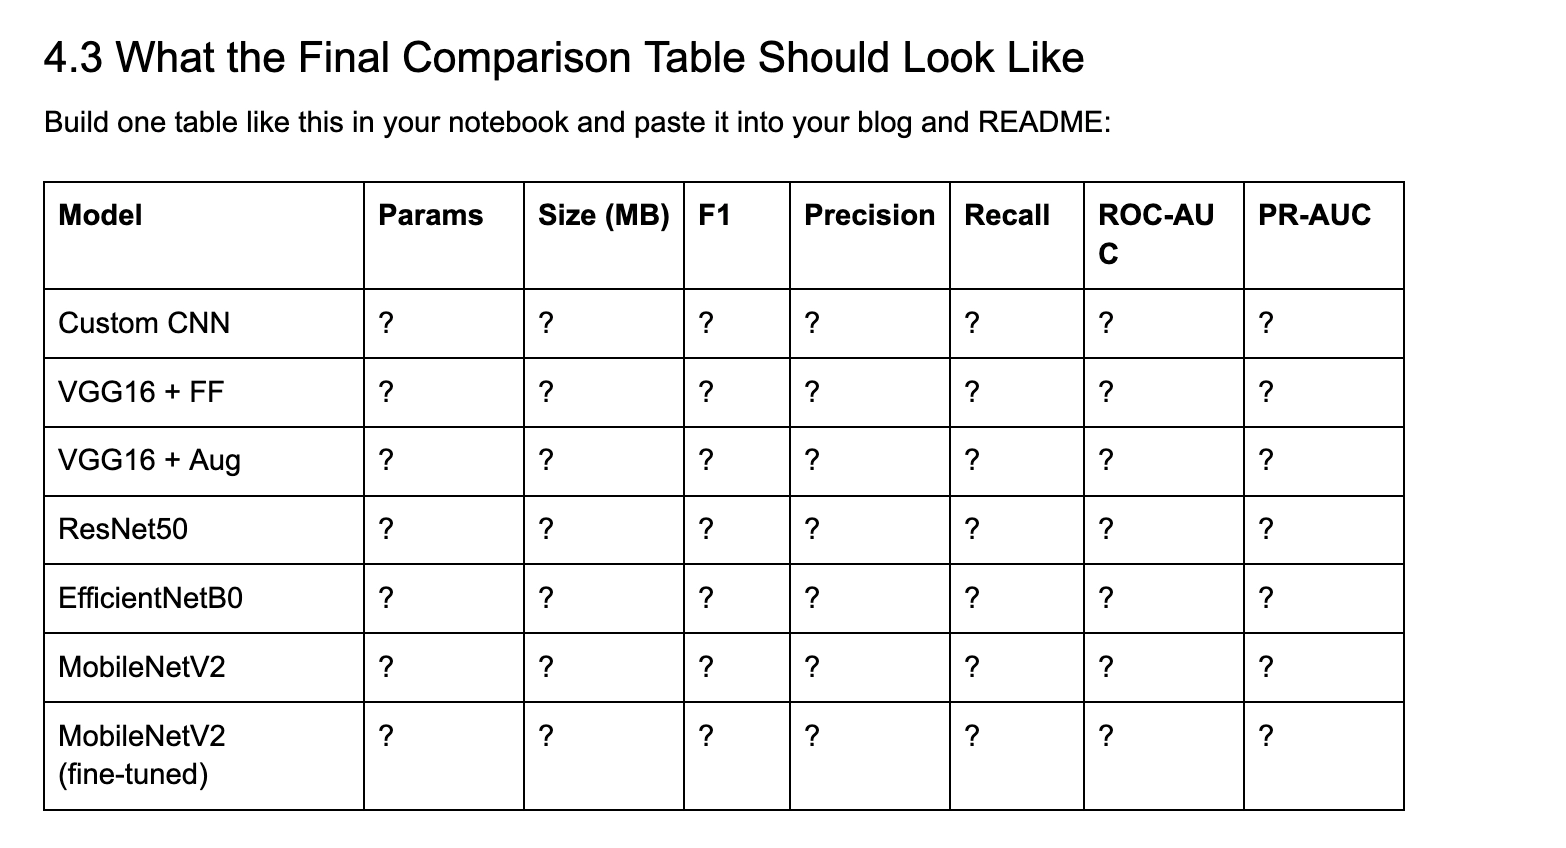

For these models:
- Call the base model e.g VGG16:

    `base_model = tf.keras.applications.VGG16(weights="imagenet",include_top=False,input_shape= input_shape)`
    `base_model.trainable = False`

- Combine the base model with a classifier 'head' similar to this (used in the best performing custom CNN):

    `transfer_model = tf.keras.Sequential([`
        `base_model,`

        `Flatten(),`
        `Dense(32,activation="relu",kernel_regularizer=l2(1e-4)),`
        `Dropout(0.4),`
        `Dense(1,activation="sigmoid")`

    `])`

- Keep the classifier head the same for each model to allow direct comparisons between each of the transfer models, and the custom CNN.

- Train and evaluate as usual.

In [2]:
from pathlib import Path
PROJ_ROOT = Path().resolve().parents[0]
DATA_DIR = PROJ_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
TRAIN_DATA_DIR = RAW_DATA_DIR / "training"
TEST_DATA_DIR = RAW_DATA_DIR / "testing"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
SFM_DATA_DIR = PROCESSED_DATA_DIR / "sfm"
DATA_PATH = SFM_DATA_DIR / "sfm_processed_data_gray.pkl"

MODELS_DIR = PROJ_ROOT / "models"
SFM_MODELS_DIR = MODELS_DIR / "sfm"


# Base
import os
import pickle
import numpy as np
import pandas as pd

# Custom
from mrp_functions import load_pickle_data

In [3]:
# Load data:
data = load_pickle_data(SFM_DATA_DIR)
data = data['sfm_processed_data_gray']
print(data.keys())

# Place in their own variables
X_train = data['X_train']
y_train = data['y_train']
X_val = data['X_val']
y_val = data['y_val']
X_test = data['X_test']
y_test = data['y_test']


# Check shapes
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

Loaded 2 pickle files:
['sfm_processed_data_sobel', 'sfm_processed_data_gray']
dict_keys(['X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test'])
(1530, 480, 270, 1) (1530,)
(383, 480, 270, 1) (383,)
(597, 480, 270, 1) (597,)


In [4]:
# Define model input shape here for consistency between model comparisons:
input_shape = X_train.shape[1:]
print(input_shape)

(480, 270, 1)


In terms of the classifier head, it may be worth using GlobalAveragePooling2D() instead of flatten:

- My custom CNN uses Flatten() only after it has already compressed the feature maps substantially with repeated pooling and a 1×1 Conv2D(16) bottleneck. So the tensor entering Flatten() is relatively small.

- The pretrained backbones to be tested here usually output feature maps with very different channel depths. If you used Flatten() for each of them, the classifier head would have a very different number of parameters depending on the backbone.

For example:
VGG16        → 7 × 7 × 512
ResNet50     → 7 × 7 × 2048
MobileNetV2  → 7 × 7 × 1280

Flattening these gives very different vector sizes, so the following Dense(32) layer would contain vastly different numbers of weights.

- Using: GlobalAveragePooling2D() instead converts each backbone's final feature map into one value per channel: H × W × C -> C
This means the classifier head stays much more comparable across transfer-learning models.

So although GlobalAveragePooling2D() is not present in my custom CNN, it is preferable for the transfer-learning comparison because it:
- Avoids giving some backbones much larger dense classifier heads than others;
- Reduces the effect of spatial output size on parameter count;
- Makes differences in performance more attributable to the backbone itself;
- Reduces overfitting risk compared with flattening large pretrained feature maps.

So to be added on the end:

`GlobalAveragePooling2D()`
`Dense(32, relu, l2=1e-4)`
`Dropout(0.4)`
`Dense(1, sigmoid)`

<h2>VGG16

VGG16 has the following structure/features:

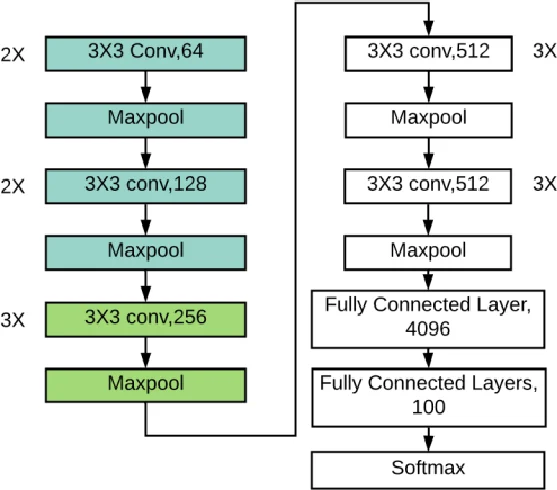

- Fully connected layers are implemented in TensorFlow as 'Dense()'.
- Maxpool layers are implemented as 'MaxPooling2D()' in TensorFlow.

<h3>Base VGG16 (No DA)

Here we are keeping the pretrained VGG16 weights but only training the classifier head. **This is an example of feature freezing (FF)**

VGG16 requires some pre-processing to make sure the data is compatiable with the model:
- Convert images a 3 channel 'pseudo' RGB i.e. from (H,W,1) to (H,W,3), as the 'imagenet' training database data images are 3-channel.
- Convert the values to 0-255 ranges rather than 0-1 i.e. undo the pixel normalisation that the images went through during data pre-processing.

In [5]:
def to_pseudo_rgb(gray: np.ndarray) -> np.ndarray:
    """
    Convert grayscale arrays to pseudo-RGB by repeating the channel.
    Accepts shapes: (H,W), (H,W,1), (N,H,W), (N,H,W,1), (H,W,3), (N,H,W,3).
    Returns array with same dtype and last dim == 3.
    """
    arr = np.asarray(gray)
    if arr.ndim == 2:
        arr = arr[..., None]
    if arr.ndim == 3:
        # could be (H,W,C) or (N,H,W)
        if arr.shape[-1] in (1, 3):
            if arr.shape[-1] == 1:
                return np.repeat(arr, 3, axis=-1)
            return arr
        # treat (N,H,W) -> add channel dim
        return np.repeat(arr[..., None], 3, axis=-1)
    if arr.ndim == 4:
        if arr.shape[-1] in (1, 3):
            if arr.shape[-1] == 1:
                return np.repeat(arr, 3, axis=-1)
            return arr
    raise ValueError(f"Unsupported input shape {arr.shape}")

def scale_0_1_to_0_255(img: np.ndarray, clip: bool = True, dtype: np.dtype = np.uint8) -> np.ndarray:
    """
    Convert image pixel values from [0,1] floats to [0,255] integers.
    Works on single images or batches (e.g. X_train shape (N,H,W,1) or (N,H,W,3)).
    If input already appears to be 0-255 (max>1) it will be rounded/converted.
    """
    arr = np.asarray(img)
    # If integer-like already and looks 0-255, just cast
    if np.issubdtype(arr.dtype, np.integer):
        return arr.astype(dtype)
    arr = arr.astype(np.float32)
    if clip:
        arr = np.clip(arr, 0.0, 1.0)
    # decide whether values are in 0-1 or already 0-255
    if arr.size == 0:
        return arr.astype(dtype)
    if arr.max() <= 1.0:
        out = np.round(arr * 255.0)
    else:
        out = np.round(arr)
    return out.astype(dtype)

def gray_to_pseudo_rgb_255(gray: np.ndarray, dtype: np.dtype = np.uint8) -> np.ndarray:
    """
    Convenience: convert grayscale (single or batch) to 3-channel and scale to 0-255 dtype.
    Example: gray_to_pseudo_rgb_255(X_train) -> shape (N,H,W,3), dtype=uint8
    """
    rgb = to_pseudo_rgb(gray)
    return scale_0_1_to_0_255(rgb, dtype=dtype)

In [6]:
# Convert grayscale datasets to pseudo-RGB (0-255 uint8) without changing order
X_train = gray_to_pseudo_rgb_255(X_train)
X_val   = gray_to_pseudo_rgb_255(X_val)
X_test  = gray_to_pseudo_rgb_255(X_test)

# Sanity checks to ensure no mismatch with labels
assert X_train.shape[0] == y_train.shape[0], "X_train/y_train length mismatch"
assert X_val.shape[0]   == y_val.shape[0],   "X_val/y_val length mismatch"
assert X_test.shape[0]  == y_test.shape[0],  "X_test/y_test length mismatch"

print("Converted shapes and dtypes:",
    X_train.shape, X_train.dtype,
    X_val.shape,   X_val.dtype,
    X_test.shape,  X_test.dtype)

print("Max and min pixel values:",X_train[0].max(), X_train[0].min())

Converted shapes and dtypes: (1530, 480, 270, 3) uint8 (383, 480, 270, 3) uint8 (597, 480, 270, 3) uint8
Max and min pixel values: 237 0


In [14]:
# Save data as pkl files for later use:
processed_data = {
        "X_train": np.asarray(X_train, dtype=np.float32),
        "y_train": np.asarray(y_train),
        "X_val": np.asarray(X_val, dtype=np.float32),
        "y_val": np.asarray(y_val),
        "X_test": np.asarray(X_test, dtype=np.float32),
        "y_test": np.asarray(y_test),
    }

size_bytes = sum(value.nbytes for value in processed_data.values() if isinstance(value, np.ndarray))
print(f"processed_data size: {size_bytes / (1024 ** 2):.2f} MiB")
data_out_path = SFM_DATA_DIR / "processed_data_vgg16.pkl"

with open(data_out_path, "wb") as file:
    pickle.dump(processed_data, file)

processed_data size: 3722.74 MiB


In [7]:
# Define input_shape here for model training repeatability:
input_shape = X_train.shape[1:]
print(input_shape)

(480, 270, 3)


In [8]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D, Input, Flatten

In [15]:
base_VGG16 =  tf.keras.applications.VGG16(weights="imagenet", # Trained on images of size 224x224. Use 'None' if *not* doing transfer learning.
                                            include_top=False, # Allows image sizes other than 224x224 to be used/
                                            input_shape=input_shape)

base_VGG16.trainable = False # FF implemented here...

In [10]:
# Create the whole model, adding the classifier 'head' at the end:
VGG16_FF = tf.keras.Sequential([
    base_VGG16, # Base VGG16 - no training

    # Classifier head:
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(1,activation="sigmoid")
])


In [11]:
base_VGG16.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 480, 270, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 480, 270, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 480, 270, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 240, 135, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 240, 135, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 240, 135, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 120, 67, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 120, 67, 256)   │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 120, 67, 256)   │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 120, 67, 256)   │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 60, 33, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 60, 33, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 60, 33, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 60, 33, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 30, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 30, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 30, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 30, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 15, 8, 512)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [12]:
VGG16_FF.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 15, 8, 512)     │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,731,137 (56.19 MB)

 Trainable params: 16,449 (64.25 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

We add a total of ~16,000 trainable parameters by implementing the clasifier head. Very small increase relative to the number of trained parameters in the base model.

Let's implement early stopping and RLROP and then train it. **See the AWS TL training script (train_sagemaker_tl.py) for the actual code.**

<h3> + DA

DA layer used for the custom CNN used here:

In [16]:
from tensorflow.keras.layers import RandomRotation, RandomTranslation, RandomZoom, RandomContrast, GaussianNoise

data_augmentation = tf.keras.Sequential([ # To be used for any TL approaches requiring DA

    # Small camera/book rotation (~±3.6 degrees)
    tf.keras.layers.RandomRotation(factor=0.01,fill_mode="reflect"),

    # Move image slightly vertically/horizontally
    tf.keras.layers.RandomTranslation(height_factor=0.05,width_factor=0.05,fill_mode="reflect"),

    # Slight variation in camera distance
    tf.keras.layers.RandomZoom(height_factor=(-0.05, 0.05), width_factor=(-0.05, 0.05), fill_mode="reflect"),

    # Small contrast variation
    tf.keras.layers.RandomContrast(factor=0.10),

    # Simulate small amounts of camera/sensor noise
    tf.keras.layers.GaussianNoise(stddev=0.015)
    ])

<h3>VGG16 Model Evaluation

In [18]:
from mrp_functions import load_model, plot_training_history, evaluate_model

Loaded model from '/Users/cameroncochrane/Data Projects/gejIeSjwpDqobLkc/models/sfm/aws_trained/tensorflow-monreader-model-20260920-132057/vgg16_ff_tl_model.keras'
Loaded history from '/Users/cameroncochrane/Data Projects/gejIeSjwpDqobLkc/models/sfm/aws_trained/tensorflow-monreader-model-20260920-132057/vgg16_ff_tl_model_history.json'


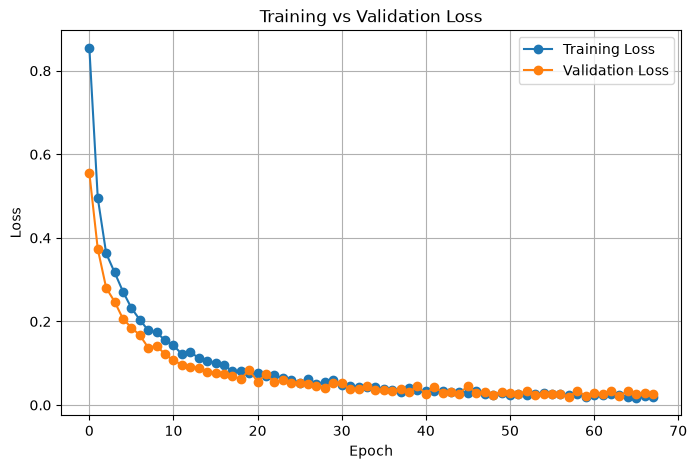

I0000 00:00:1789926064.147926 5282641 service.cc:153] XLA service 0x17fdf2360 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1789926064.148214 5282641 service.cc:161]   StreamExecutor [0]: Host, Default Version (Driver: 0.0.0; Runtime: 0.0.0; Toolkit: 0.0.0; DNN: 0.0.0)
I0000 00:00:1789926064.220938 5282641 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
W0000 00:00:1789926064.653205 5541435 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.
I0000 00:00:1789926064.734799 5282641 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Test set evaluation:
  loss: 0.036685436964035034
  compile_metrics: 0.9882746934890747

Classification Report:
              precision    recall  f1-score   support

     notflip       0.98      1.00      0.99       307
        flip       1.00      0.98      0.99       290

    accuracy                           0.99       597
   macro avg       0.99      0.99      0.99       597
weighted avg       0.99      0.99      0.99       597

Macro F1-score: 0.9883


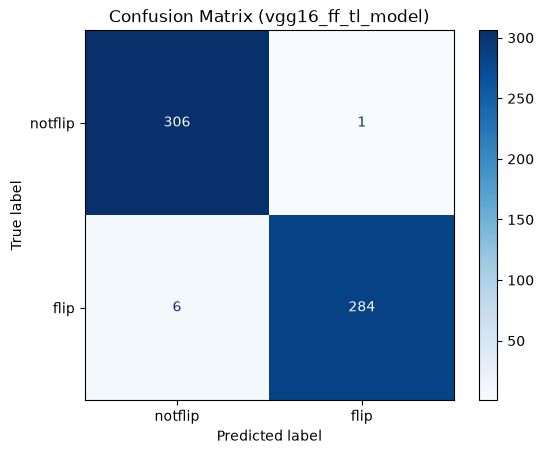

In [ ]:
# Results (FF):
train_vgg16_ff_tl_model = False

job_name = "tensorflow-monreader-model-20260920-132057" 
model_name = "vgg16_ff_tl_model.keras" 
history_name = "vgg16_ff_tl_model_history.json"

SFM_AWS_MODELS_DIR = SFM_MODELS_DIR / "aws_trained"
AWS_MODEL_DIR = SFM_AWS_MODELS_DIR / job_name


if train_vgg16_ff_tl_model == False:
    vgg16_ff_tl_model,vgg16_ff_tl_model_history =  load_model("vgg16_ff_tl_model", AWS_MODEL_DIR)
    plot_training_history(vgg16_ff_tl_model_history, metric='loss')


vgg16_ff_tl_model_to_eval = vgg16_ff_tl_model if train_vgg16_ff_tl_model == False else vgg16_ff_tl_model

# Guard against accidentally passing the training History object
if isinstance(vgg16_ff_tl_model_to_eval, tf.keras.callbacks.History):
    vgg16_ff_tl_model_to_eval = vgg16_ff_tl_model

# Ensure rank is known and the arrays are concrete numpy arrays
X_eval = np.asarray(X_test, dtype=np.float32)
y_eval = np.asarray(y_test, dtype=np.int32).reshape(-1)

eval_results = evaluate_model(
    vgg16_ff_tl_model_to_eval,
    X_eval,
    y_eval,
    class_names=('notflip', 'flip'),
    plot_name="vgg16_ff_tl_model"
)

Loaded model from '/Users/cameroncochrane/Data Projects/gejIeSjwpDqobLkc/models/sfm/aws_trained/tensorflow-monreader-model-20260920-171931/vgg16_ff_da_tl_model.keras'
Loaded history from '/Users/cameroncochrane/Data Projects/gejIeSjwpDqobLkc/models/sfm/aws_trained/tensorflow-monreader-model-20260920-171931/vgg16_ff_da_tl_model_history.json'


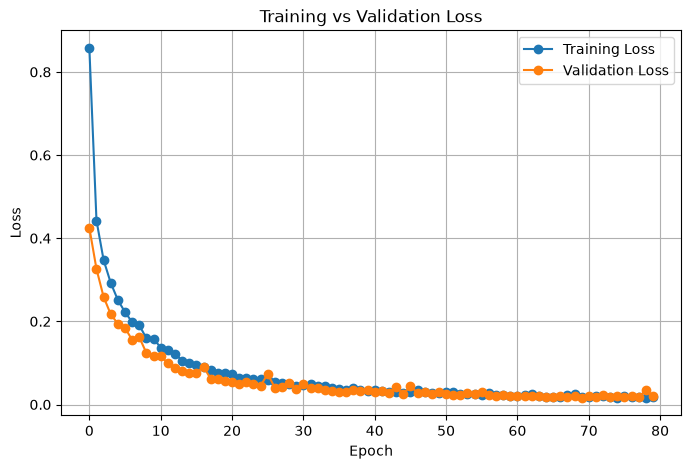

Test set evaluation:
  loss: 0.03572160750627518
  compile_metrics: 0.9916247725486755

Classification Report:
              precision    recall  f1-score   support

     notflip       0.98      1.00      0.99       307
        flip       1.00      0.98      0.99       290

    accuracy                           0.99       597
   macro avg       0.99      0.99      0.99       597
weighted avg       0.99      0.99      0.99       597

Macro F1-score: 0.9916


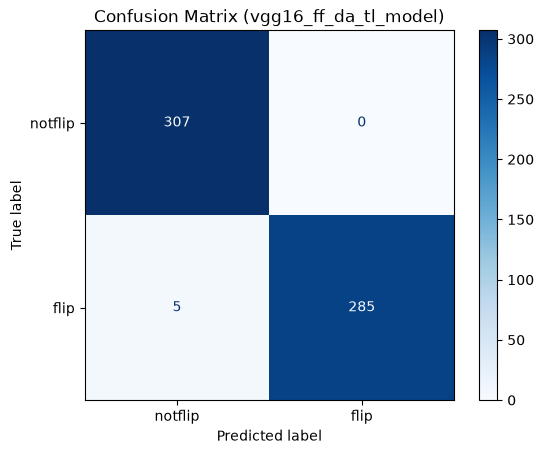

In [20]:
# Results (DA):
train_vgg16_ff_da_tl_model = False

job_name = "tensorflow-monreader-model-20260920-171931" 
model_name = "vgg16_ff_da_tl_model.keras" 
history_name = "vgg16_ff_da_tl_model_history.json"

SFM_AWS_MODELS_DIR = SFM_MODELS_DIR / "aws_trained"
AWS_MODEL_DIR = SFM_AWS_MODELS_DIR / job_name


if train_vgg16_ff_da_tl_model == False:
    vgg16_ff_da_tl_model,vgg16_ff_da_tl_model_history =  load_model("vgg16_ff_da_tl_model", AWS_MODEL_DIR)
    plot_training_history(vgg16_ff_da_tl_model_history, metric='loss')


vgg16_ff_da_tl_model_to_eval = vgg16_ff_da_tl_model if train_vgg16_ff_da_tl_model == False else vgg16_ff_da_tl_model

# Guard against accidentally passing the training History object
if isinstance(vgg16_ff_da_tl_model_to_eval, tf.keras.callbacks.History):
    vgg16_ff_da_tl_model_to_eval = vgg16_ff_da_tl_model

# Ensure rank is known and the arrays are concrete numpy arrays
X_eval = np.asarray(X_test, dtype=np.float32)
y_eval = np.asarray(y_test, dtype=np.int32).reshape(-1)

eval_results = evaluate_model(
    vgg16_ff_da_tl_model_to_eval,
    X_eval,
    y_eval,
    class_names=('notflip', 'flip'),
    plot_name="vgg16_ff_da_tl_model"
)

Very good performance when considering paramenter size compared with my custom CNN, but the 0.1-0.4 % increase in val accuracy may not be worth it. 
- DA improves the model slightly.
- Predictions take much longer to carry out on these two models compared with my custom CNN. May not be ideal for a mobile app which would have limited hardware capabilities and would require quick predictions.